In [51]:
import numpy as np
import matplotlib.pyplot as plt

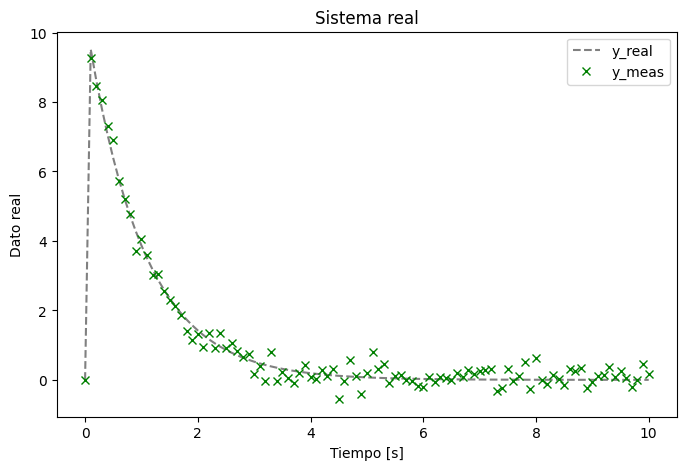

In [52]:
# Primero simulemos el sistema "real"
M = 101
delta = 0.1
std = 0.5

y = np.zeros((M,1))
y_meas = np.zeros((M,1))
u = np.zeros((M,1))
u[0,:] = 100

# PHI - GAMMA
x = [0.9048, 0.0952] # Coeficientes de las h (en este caso, y-u)

for j in range(1,M):
    y[j] = x[0] * y[j-1] + x[1] * u[j-1]
    y_meas[j] = y[j] + np.random.normal(0, std**2)

t = np.arange(M) * delta

plt.figure(figsize=(8,5))
plt.title("Sistema real")
plt.xlabel("Tiempo [s]")
plt.ylabel("Dato real")
plt.plot(t, y, '--', c='gray', label='y_real')
plt.plot(t, y_meas, 'x', c='green', label='y_meas')
plt.legend()
plt.show()

(100, 2) (101, 1) (101, 1)
X_est = [0.89875819 0.09262227]
X_real = [0.9048, 0.0952]


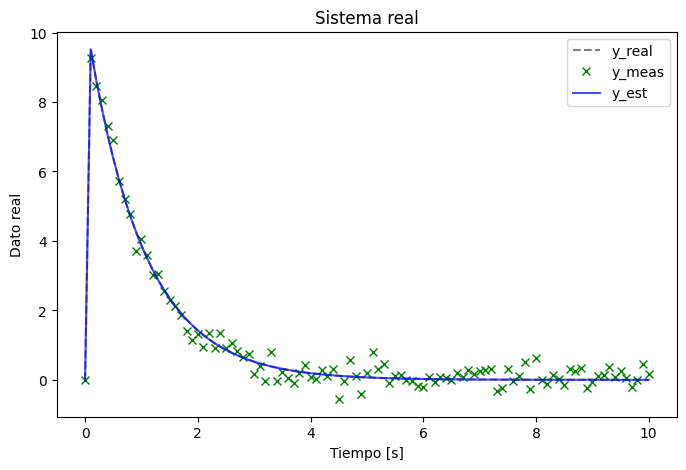

In [56]:
# Ahora estimemos los coeficientes a partir de y_meas
y_est = np.zeros((M, 1))
H = np.hstack((y_meas[:-1],u[:-1]))
print(H.shape, y_est.shape, y_meas.shape)

# OJO, ES y[n+1] = algo * y[n] + otra cosa
x_est = np.linalg.inv(H.T @ H) @ H.T @ y_meas[1:] # <-- por esto lo digo
print(f"X_est = {x_est.flatten()}")
print(f"X_real = {x}")

for j in range(1, M):
    y_est[j] = x_est[0] * y_est[j] + x_est[1] * u[j]

plt.figure(figsize=(8,5))
plt.title("Sistema real")
plt.xlabel("Tiempo [s]")
plt.ylabel("Dato real")
plt.plot(t, y, '--', c='gray', label='y_real')
plt.plot(t, y_meas, 'x', c='green', label='y_meas')
plt.plot(t, y, c='blue', label='y_est', alpha=0.7)
plt.legend()
plt.show()